# AdaBoost (Adaptive Boosting)

## What Is AdaBoost?

AdaBoost is a **boosting** ensemble algorithm. Unlike Random Forest, which builds trees in parallel independently, AdaBoost builds weak learners **sequentially** — each new learner pays extra attention to the examples the previous ones got wrong.

The final prediction is a **weighted vote** across all weak learners:

$$F(\mathbf{x}) = \text{sign}\left(\sum_{t=1}^{T} \alpha_t h_t(\mathbf{x})\right)$$

Where:

- $T$ is the total number of weak learners
- $h_t(\mathbf{x})$ is the prediction of the $t$-th weak learner
- $\alpha_t$ is the weight assigned to learner $t$ based on its accuracy
- $\text{sign}(\cdot)$ converts the weighted sum into a class label ($+1$ or $-1$)

Learners that perform better get a higher $\alpha_t$ and therefore more influence over the final decision.

## The Core Idea: Weak Learners

A **weak learner** is a model that performs only slightly better than random guessing — just above 50% accuracy for binary classification. In AdaBoost, the default weak learner is a **Decision Stump**: a Decision Tree with depth 1, which makes exactly one binary split.

A single stump is nearly useless. But AdaBoost's insight is:

> *If you combine many weak learners, each focused on the mistakes of the last, you get a powerful strong learner.*

This is the fundamental idea of **boosting** — bias reduction through sequential error correction. Compare this to Random Forest, which reduces **variance** by averaging many independent high-complexity trees. AdaBoost reduces **bias** by iteratively correcting errors with simple models.

## The Mathematics Step by Step

### Step 1: Initialize Sample Weights

All $N$ training samples start with equal weight:

$$w_i = \frac{1}{N}, \quad i = 1, 2, \ldots, N$$

These weights represent how much attention the next learner should pay to each sample.

### Step 2: Train a Weak Learner

Train weak learner $h_t$ on the **weighted** training data. The learner tries harder to correctly classify samples with higher weights.

### Step 3: Compute Weighted Error

Measure how poorly the learner did, taking sample weights into account:

$$\epsilon_t = \sum_{i=1}^{N} w_i \cdot \mathbb{1}\left[y_i \neq h_t(\mathbf{x}_i)\right]$$

Where $\mathbb{1}[\cdot]$ is the indicator function — it equals 1 if the prediction is wrong and 0 if correct. Because the weights sum to 1, $\epsilon_t$ is a weighted fraction of misclassified samples.

### Step 4: Compute Learner Weight

How much should this learner's vote count in the final ensemble?

$$\alpha_t = \frac{1}{2} \ln\left(\frac{1 - \epsilon_t}{\epsilon_t}\right)$$

The relationship is intuitive:

- If $\epsilon_t$ is small (learner did well) $\rightarrow$ $\alpha_t$ is large $\rightarrow$ strong influence
- If $\epsilon_t = 0.5$ (no better than random) $\rightarrow$ $\alpha_t = 0$ $\rightarrow$ no influence
- If $\epsilon_t > 0.5$ (worse than random) $\rightarrow$ $\alpha_t < 0$ $\rightarrow$ prediction is flipped

### Step 5: Update Sample Weights

Increase the weight of misclassified samples, decrease the weight of correctly classified ones:

$$w_i \leftarrow w_i \cdot e^{-\alpha_t y_i h_t(\mathbf{x}_i)}$$

Where $y_i \in \{-1, +1\}$ is the true label and $h_t(\mathbf{x}_i) \in \{-1, +1\}$ is the prediction.

When the prediction is **correct**, $y_i h_t(\mathbf{x}_i) = +1$, so the exponent is $-\alpha_t$ (negative) and the weight **decreases**.

When the prediction is **wrong**, $y_i h_t(\mathbf{x}_i) = -1$, so the exponent is $+\alpha_t$ (positive) and the weight **increases**.

After updating, normalize all weights so they sum to 1:

$$w_i \leftarrow \frac{w_i}{\sum_{j=1}^{N} w_j}$$

### Step 6: Repeat

Return to Step 2 and train the next weak learner on the updated weights. Repeat for $T$ rounds.

## Why AdaBoost Works: The Bias–Variance View

A single Decision Stump has **high bias** — it can only draw one axis-aligned line and cannot capture complex patterns. Boosting addresses this directly.

Each round, the new learner focuses on the hardest examples — the ones that keep getting misclassified. Over many rounds, the ensemble builds up a complex, highly accurate decision boundary from a sequence of simple rules. The bias decreases with each round.

However, because AdaBoost keeps focusing on difficult and often **noisy** examples, outliers and mislabeled points accumulate very high weights. The algorithm begins to overfit to noise. This is why AdaBoost is sensitive to noisy datasets — a weakness that later algorithms like Gradient Boosting address more carefully.

## When To Use AdaBoost

**Use AdaBoost when:**

- The dataset is small to medium in size
- A single Decision Tree underfits (high bias)
- The data is relatively clean with few outliers
- You want a simple, well-understood boosting baseline

**Avoid AdaBoost when:**

- The dataset is noisy or contains many outliers — these accumulate disproportionately large weights and dominate training
- The dataset is very large — sequential training is slower than parallel methods like Random Forest
- Real-time or low-latency inference is required

## Random Forest vs AdaBoost

| Property | Random Forest | AdaBoost |
|---|---|---|
| Strategy | Bagging | Boosting |
| Training order | Parallel (independent trees) | Sequential (each corrects the last) |
| Primary error reduced | Variance | Bias |
| Tree depth | Deep trees (low bias) | Shallow stumps (depth = 1) |
| Tree weighting | Equal votes | Weighted votes ($\alpha_t$) |
| Sample weighting | Bootstrap resampling | Adaptive weight updates |
| Noise sensitivity | Robust | Sensitive |
| Speed | Faster (parallelizable) | Slower (sequential) |

**Rule of thumb:** If your model is overfitting, try Random Forest (variance reduction). If your model is underfitting, try AdaBoost or Gradient Boosting (bias reduction).

https://www.youtube.com/watch?v=LsK-xG1cLYA

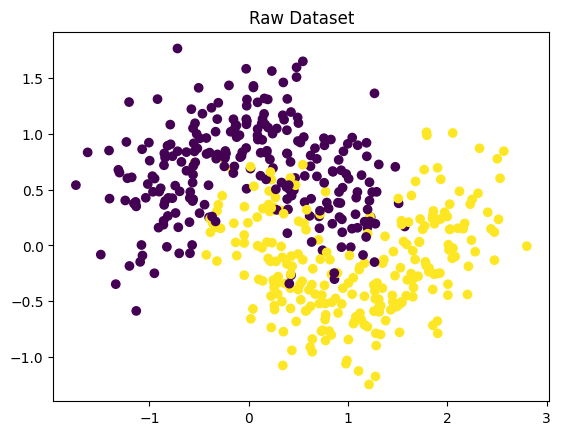

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.datasets import make_moons

# Non-linear dataset
X, y = make_moons(n_samples=500, noise=0.3, random_state=42)

# Visualize raw data
plt.scatter(X[:, 0], X[:, 1], c=y)
plt.title("Raw Dataset")
plt.show()

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

base_learner = DecisionTreeClassifier(max_depth=1)

ada = AdaBoostClassifier(
    estimator=base_learner,
    n_estimators=50,        # number of weak learners
    learning_rate=1.0,
    random_state=42
)

ada.fit(X_train, y_train)

,"estimator estimator: object, default=NoneThe base estimator from which the boosted ensemble is built.Support for sample weighting is required, as well as proper``classes_`` and ``n_classes_`` attributes. If ``None``, thenthe base estimator is :class:`~sklearn.tree.DecisionTreeClassifier`initialized with `max_depth=1`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",DecisionTreeC...r(max_depth=1)
,"n_estimators n_estimators: int, default=50The maximum number of estimators at which boosting is terminated.In case of perfect fit, the learning procedure is stopped early.Values must be in the range `[1, inf)`.",50
,"learning_rate learning_rate: float, default=1.0Weight applied to each classifier at each boosting iteration. A higherlearning rate increases the contribution of each classifier. There isa trade-off between the `learning_rate` and `n_estimators` parameters.Values must be in the range `(0.0, inf)`.",1.0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given at each `estimator` at eachboosting iteration.Thus, it is only used when `estimator` exposes a `random_state`.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",1
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None


In [5]:
y_pred = ada.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.89

Confusion Matrix:
 [[42  1]
 [10 47]]

Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.98      0.88        43
           1       0.98      0.82      0.90        57

    accuracy                           0.89       100
   macro avg       0.89      0.90      0.89       100
weighted avg       0.91      0.89      0.89       100



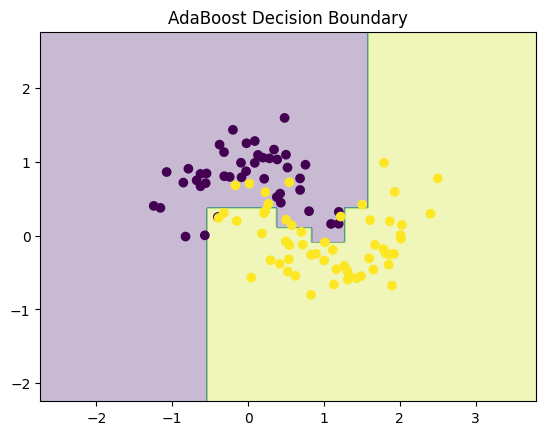

In [6]:
x_min, x_max = X[:, 0].min()-1, X[:, 0].max()+1
y_min, y_max = X[:, 1].min()-1, X[:, 1].max()+1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

grid = np.c_[xx.ravel(), yy.ravel()]
Z = ada.predict(grid)
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test)
plt.title("AdaBoost Decision Boundary")
plt.show()